###Taller Modelos Lineales
Victoria Céspedes González

Antonia González Lillo

####Carga de archivos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from google.colab import files
import io

# --- 1. Base de datos VENTAS ---
print("Por favor, sube el archivo de VENTAS:")
up_ventas = files.upload()
nom_ventas = list(up_ventas.keys())[0]
df = pd.read_csv(io.BytesIO(up_ventas[nom_ventas]), sep=r'\s+')
print("¡Ventas cargado con éxito!\n")

# --- 2. Base de datos DATOS (Biomasa/Suelo) ---
print("Por favor, sube el archivo de DATOS:")
up_datos = files.upload()
nom_datos = list(up_datos.keys())[0]
df_suelo = pd.read_csv(io.BytesIO(up_datos[nom_datos]), sep=r'\s+')
print("¡Datos cargado con éxito!\n")

# --- 3. Base de datos ESPERANZA ---
print("Por favor, sube el archivo de ESPERANZA:")
up_esperanza = files.upload()
nom_esperanza = list(up_esperanza.keys())[0]
df_esp = pd.read_csv(io.BytesIO(up_esperanza[nom_esperanza]), sep=r'\s+')
print("¡Esperanza cargado con éxito!")

Por favor, sube el archivo de VENTAS:


Saving ventas.txt to ventas.txt
¡Ventas cargado con éxito!

Por favor, sube el archivo de DATOS:


Saving datos.txt to datos.txt
¡Datos cargado con éxito!

Por favor, sube el archivo de ESPERANZA:


Saving esperanza.txt to esperanza.txt
¡Esperanza cargado con éxito!


####Ejercicio 1

In [ ]:
#dimensiones y estructura
print("Dimensiones de la base:", df.shape)
print("\nPrimeras filas:")
print(df.head())

#datos faltantes
print("\nDatos faltantes por columna:")
print(df.isnull().sum())

#medidas descriptivas
print("\nEstadísticos descriptivos:")
print(df.describe())

#matriz de correlaciones
print("\nMatriz de correlaciones:")
matriz_corr = df.corr()
print(matriz_corr)

# Exportar las estadísticas descriptivas (describe)
print(df.describe().to_latex(float_format="%.2f"))

# Exportar la matriz de correlaciones (corr)
print(df.corr().to_latex(float_format="%.3f"))



<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2984/1722213401.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('ventas.txt', sep='\s+')


Dimensiones de la base: (180, 4)

Primeras filas:
      tv  radio  periodico  ventas
0  230.1   37.8       69.2    22.1
1   44.5   39.3       45.1    10.4
2   17.2   45.9       69.3     9.3
3  151.5   41.3       58.5    18.5
4  180.8   10.8       58.4    12.9

Datos faltantes por columna:
tv           0
radio        0
periodico    0
ventas       0
dtype: int64

Estadísticos descriptivos:
               tv       radio   periodico      ventas
count  180.000000  180.000000  180.000000  180.000000
mean   144.316667   22.787222   30.205556   13.750000
std     86.720853   15.082896   22.135289    5.164322
min      0.700000    0.000000    0.300000    1.600000
25%     72.350000    9.300000   12.275000   10.250000
50%    140.800000   21.500000   24.250000   12.650000
75%    217.025000   36.650000   45.125000   17.125000
max    296.400000   49.600000  114.000000   27.000000

Matriz de correlaciones:
                 tv     radio  periodico    ventas
tv         1.000000  0.010521   0.048168  0.77

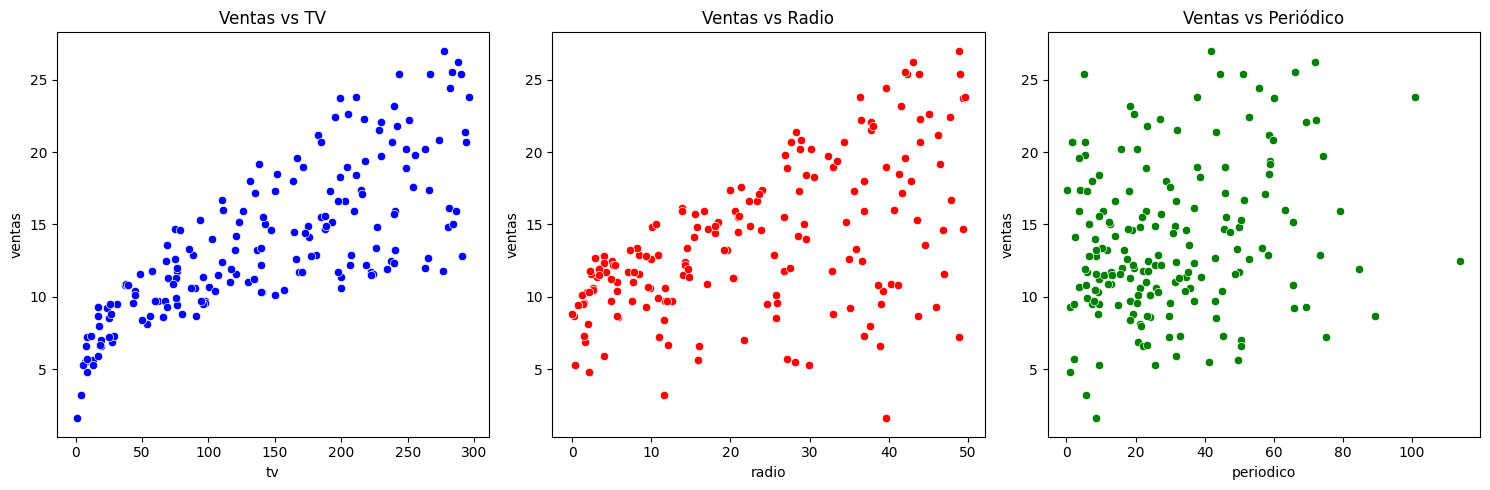

In [ ]:
#gráficos de dispersión entre ventas y cada predictor
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(data=df, x='tv', y='ventas', ax=axs[0], color='blue')
axs[0].set_title('Ventas vs TV')

sns.scatterplot(data=df, x='radio', y='ventas', ax=axs[1], color='red')
axs[1].set_title('Ventas vs Radio')

sns.scatterplot(data=df, x='periodico', y='ventas', ax=axs[2], color='green')
axs[2].set_title('Ventas vs Periódico')

plt.tight_layout()
plt.show()

Interpretaciones:
Al ver los gráficos y las correlaciones se ve una relación lineal positiva entre ventas y tv, moderada entre ventas y radio, y entre ventas y periódico mucho más débil y dispersa.

In [ ]:
#variables
X = df[['tv', 'radio', 'periodico']]
y = df['ventas']

#intercepto(beta_0)
X = sm.add_constant(X)

#ajustar modelo con mco
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

# Supongamos que tu modelo se llama "modelo", "modelo_simple" o "modelo_final"
# Guardas el resumen estadístico
resumen_modelo = modelo.summary()

# Lo exportas a LaTeX
print(resumen_modelo.as_latex())

                            OLS Regression Results                            
Dep. Variable:                 ventas   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     470.0
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           9.58e-84
Time:                        03:46:58   Log-Likelihood:                -352.57
No. Observations:                 180   AIC:                             713.1
Df Residuals:                     176   BIC:                             725.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9635      0.334      8.861      0.0

Interpretaciones:

"const" es el beta_0, representa el valor esperado de las ventas si  el valor de la tv, radio y periódico fueran 0.

"tv" sería el beta_1, como tiene signo positivo indica que manteniendo constantes los presupuestos de radio y periódico, el aumento de una unidad del presupuesto de tv aumenta en 0.0458 unidades de las ventas. Por el valor-p siendo 0.000 tiene alta significancia estadística.

"radio" sería el beta_2, como tiene signo positivo indica que manteniendo los presupuestos de tv y periódico constantes, el aumento de una unidad del presupuesto de radio aumenta en 0.1850 unidades de las ventas. Por el valor-p esto tiene alta significancia estadística.

"periodico" sería el beta_3, presenta signo negativo que significaría una disminución en ventas con al aumentar la inversión en periódico, pero como el valor-p es bastante alto (0.861) indicaría que no existe evidencia estadística de que periódico influya en las ventas manteniendo tv y radio constantes.

"F-statistic" sería el estadístico F, que entrega un valor de 470.0, al ser un valor tan superior a 1 indicaría que el modelo efectivamente sirve para explicar y predecir las ventas.

"Prob (F-statistic)" sería el valor-p asociado al estadístico F, al ser un valor que es prácticamente 0 indicaría que el resultado obtenido con el la prueba F es estadísticamente significativo.

In [ ]:
#vector con los valores: [constante, tv, radio, periodico]
valores_c = [1, 147.05, 23.3, 31.0]

#predicción
prediccion_c = modelo.get_prediction(valores_c)

#intervalo de confianza (alpha=0.05 es 95%)
print(prediccion_c.summary_frame(alpha=0.05)[['mean', 'mean_ci_lower', 'mean_ci_upper']])

# Para el intervalo de confianza (1c)
tabla_confianza = prediccion_c.summary_frame(alpha=0.05)[['mean', 'mean_ci_lower', 'mean_ci_upper']]
print(tabla_confianza.to_latex(index=False, float_format="%.3f"))

        mean  mean_ci_lower  mean_ci_upper
0  13.969072      13.713511      14.224633
\begin{tabular}{rrr}
\toprule
mean & mean_ci_lower & mean_ci_upper \\
\midrule
13.969 & 13.714 & 14.225 \\
\bottomrule
\end{tabular}



Interpretación: Con un nivel de confianza del 95%, podemos estimar que el promedio de ventas para todas las regiones que inviertan exactamente 147.05 millones en tv, 23.3 millones en radio y 31 millones en periódicos, se encuentra contenido entre 13.71 y 14.22 millones



In [ ]:
#vector con los valores para la nueva sucursal
valores_d = [1, 160.0, 26.7, 35.1]

prediccion_d = modelo.get_prediction(valores_d)

#intervalo de predicción
print(prediccion_d.summary_frame(alpha=0.05)[['mean', 'obs_ci_lower', 'obs_ci_upper']])

# Para el intervalo de predicción (1d)
tabla_prediccion = prediccion_d.summary_frame(alpha=0.05)[['mean', 'obs_ci_lower', 'obs_ci_upper']]
print(tabla_prediccion.to_latex(index=False, float_format="%.3f"))

        mean  obs_ci_lower  obs_ci_upper
0  15.186188     11.751527     18.620849
\begin{tabular}{rrr}
\toprule
mean & obs_ci_lower & obs_ci_upper \\
\midrule
15.186 & 11.752 & 18.621 \\
\bottomrule
\end{tabular}



Interpretación: Con un nivel de confianza del 95%, se estima que el volumen de ventas para esta nueva sucursal, con una inversión de 160 millones en tv, 26.7 millones en radio y 35.1 millones en periódico, estará entre 11.75 y 18.62 millones.

1(e)

Esperanza condicional (el intervalo de confianza): Aquí se calcula el promedio general, la única incertidumbre existe es que la fórmula matemática podría no ser exacta, al ser promedio general no existe incertidumbre por variabilidad porque estos se cancelan.

Nueva observación (intervalo de predicción): Aquí se calcula para una sucursal única y nueva, existe la incertidumbre por la exactitud de la fórmula matemática y también de la variabilidad propia de esa observación, esto porque es un Y nuevo futuro que viene con su propio error agregado.

####Ejercicio 2

In [ ]:
#estructura y dimensiones
print("Dimensiones de la base:", df_suelo.shape)
print("\nEstructura (info):")
print(df_suelo.info())

#revisión de datos faltantes
print("\nDatos faltantes por columna:")
print(df_suelo.isnull().sum())

#estadísticos descriptivos
print("\nEstadísticos descriptivos:")
print(df_suelo.describe())

#matriz de correlaciones
print("\nMatriz de correlaciones:")
print(df_suelo.corr())

# Exportar las estadísticas descriptivas (describe)
print(df.describe().to_latex(float_format="%.2f"))

# Exportar la matriz de correlaciones (corr)
print(df.corr().to_latex(float_format="%.3f"))


Dimensiones de la base: (40, 6)

Estructura (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   biomasa    40 non-null     int64  
 1   salinidad  40 non-null     int64  
 2   pH         40 non-null     float64
 3   K          40 non-null     float64
 4   Na         40 non-null     float64
 5   Zn         40 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 2.0 KB
None

Datos faltantes por columna:
biomasa      0
salinidad    0
pH           0
K            0
Na           0
Zn           0
dtype: int64

Estadísticos descriptivos:
           biomasa  salinidad         pH            K            Na         Zn
count    40.000000  40.000000  40.000000    40.000000     40.000000  40.000000
mean    940.700000  30.250000   4.473750   789.816500  16806.167500  18.288488
std     608.973504   3.607329   1.148856   295.458519   7061.114536   7.4

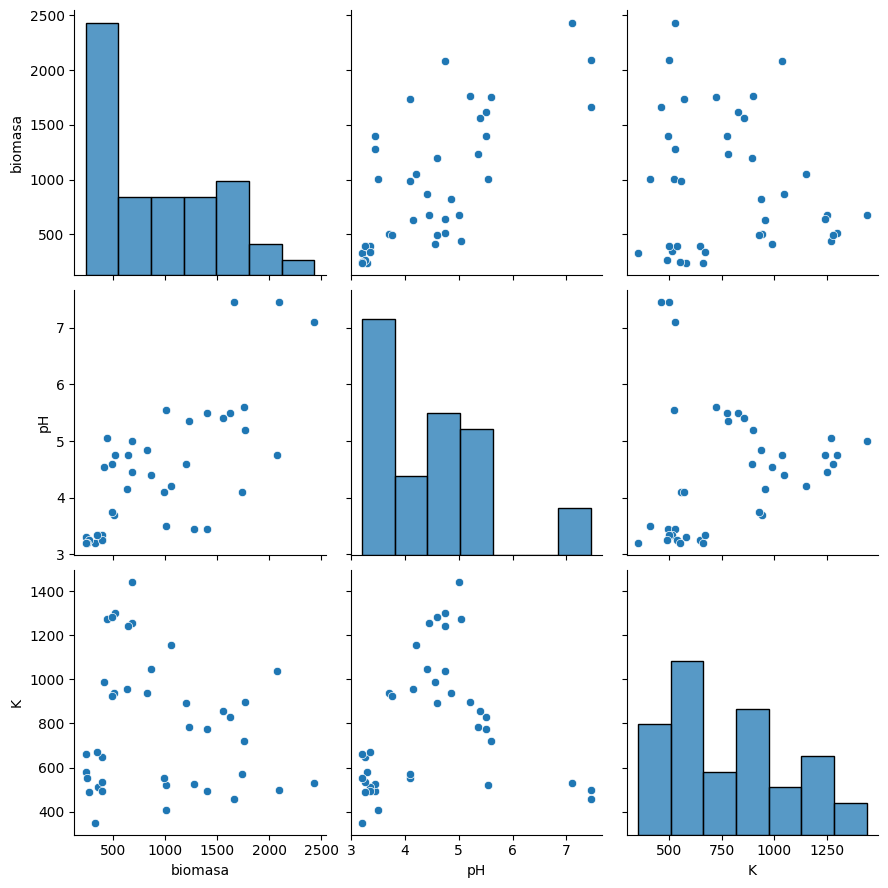

In [ ]:
#gráficos entre Y (biomasa), X2 (pH) y X3 (K)
sns.pairplot(data=df_suelo, vars=['biomasa', 'pH', 'K'], height=3)
plt.show()

Interpretaciones:

En la matriz de correlaciones biomasa y ph presentan una correlación positiva fuerte de 0.722. Esto indica numéricamente que los suelos con mayor pH tienden a tener mayor biomasa.

Biomasa y K (potasio) presentan una correlación negativa muy débil de -0.1310, por lo que el potasio por sí solo no parece explicar mucho los cambios en la biomasa.

Ph y K tienen una correlación baja 0.1483, lo que sugiere ausencia de colinealidad fuerte entre ambos predictores.

Los histogramas presentan la distribución de cada variable individual, biomasa presenta un sesgo a la derecha. El gráfico de dispersión de biomasa y ph demuestra una tendencia positiva, el resto de gráficos de dispersión están más dispersos sin presentar tendencia clara, esto corrobora la baja correlación observada anteriormente.

In [ ]:
#definir variable independiente X2 (pH) y dependiente Y (biomasa)
X2 = df_suelo['pH']
y = df_suelo['biomasa']

#beta_0
X2_const = sm.add_constant(X2)

#ajustar el modelo simple
modelo_simple = sm.OLS(y, X2_const).fit()

print(modelo_simple.summary())

# Supongamos que tu modelo se llama "modelo", "modelo_simple" o "modelo_final"
# Guardas el resumen estadístico
resumen_modelo = modelo_simple.summary()

# Lo exportas a LaTeX
print(resumen_modelo.as_latex())

                            OLS Regression Results                            
Dep. Variable:                biomasa   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     41.54
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.40e-07
Time:                        04:59:01   Log-Likelihood:                -297.95
No. Observations:                  40   AIC:                             599.9
Df Residuals:                      38   BIC:                             603.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -773.0621    274.307     -2.818      0.0

Interpretaciones:

"const" es el beta_0, representa el valor esperado de la biomasa si el nivel del pH en el suelo fuera exactamente 0. (Aunque en la vida real un pH de 0 no tenga sentido biológico, esta es su interpretación matemática).  

"pH" sería el beta_2, como tiene signo positivo indica que el aumento de una unidad en el nivel de pH aumenta en 383.0706 unidades la biomasa. A diferencia del ejercicio anterior, como esta es una regresión simple, este efecto se calcula ignorando por completo el resto de las variables. Por el valor-p siendo 0.000 esto tiene alta significancia estadística.   

"F-statistic" sería el estadístico F, que entrega un valor de 41.54, al ser un valor superior a 1 indicaría que el modelo efectivamente sirve para explicar la biomasa.   

"Prob (F-statistic)" sería el valor-p asociado al estadístico F, al ser un valor que es prácticamente 0 (1.40e-07) indicaría que el resultado obtenido con la prueba F es estadísticamente significativo.

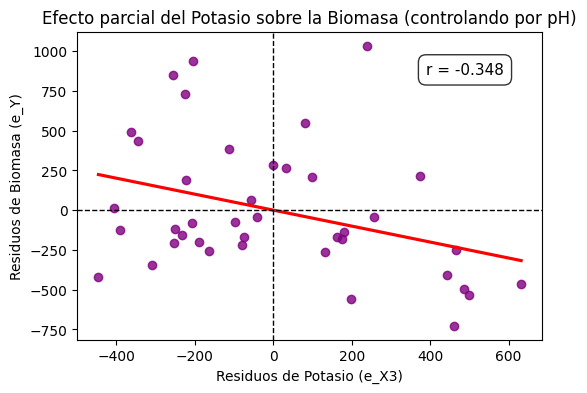

In [ ]:
#ajuste de la regresión Y ~ X2 y obtención de residuos (e_Y)
e_Y = modelo_simple.resid

#ajuste de la regresión X3 ~ X2 y obtención de residuos (e_X3)
X3 = df_suelo['K']
modelo_X3_X2 = sm.OLS(X3, X2_const).fit()
e_X3 = modelo_X3_X2.resid

# Calcular el coeficiente de correlación (r)
r_val = e_X3.corr(e_Y)

# gráfico de dispersión de e_Y versus e_X3 con línea de regresión limpia
fig, ax = plt.subplots(figsize=(6, 4))

# Agregamos ci=None para eliminar la banda de confianza
sns.regplot(x=e_X3, y=e_Y, ax=ax, color='purple', line_kws={"color": "red"}, ci=None)

ax.set_xlabel('Residuos de Potasio (e_X3)')
ax.set_ylabel('Residuos de Biomasa (e_Y)')
ax.set_title('Efecto parcial del Potasio sobre la Biomasa (controlando por pH)')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Agregar el recuadro con el valor de r
# Usamos transform=ax.transAxes para usar coordenadas relativas (de 0 a 1) y no tener que adivinar las coordenadas del gráfico
ax.text(0.75, 0.90, f'r = {r_val:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8))

plt.show()

Interpretaciones:

"e_Y" serían los residuos de la biomasa, representa la parte de la biomasa que el modelo con el ph no fue capaz de predecir o explicar.

"e_X3" serían los residuos del ph, representa la variación del potasio que es totalmente independiente del nivel de ph.

Se observa una clara tendencia negativa. Esto significa que, manteniendo constante el ph, el aumento de potasio en el suelo está asociado con una disminución en la biomasa de la especie de pasto

In [ ]:
#agregamos la constante a los residuos de potasio
e_X3_const = sm.add_constant(e_X3)

# Ajustamos la regresión usando los residuos de la biomasa (e_Y) como variable dependiente
modelo_residuos = sm.OLS(e_Y, e_X3_const).fit()

#guardamos y mostramos la pendiente estimada (gamma)
gamma_estimado = modelo_residuos.params[0]
print(modelo_residuos.summary())

# Supongamos que tu modelo se llama "modelo", "modelo_simple" o "modelo_final"
# Guardas el resumen estadístico
resumen_modelo = modelo_residuos.summary()

# Lo exportas a LaTeX
print(resumen_modelo.as_latex())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     5.253
Date:                Tue, 22 Sep 2026   Prob (F-statistic):             0.0275
Time:                        04:59:13   Log-Likelihood:                -295.36
No. Observations:                  40   AIC:                             594.7
Df Residuals:                      38   BIC:                             598.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.119e-13     63.195  -1.77e-15      1.0

Interpretación:

"const" representa el beta_0, es un valor que es prácticamente 0, lo que tiene sentido matemáticamente, ya que por la propiedad de los mínimos cuadrados ordinarios, el promedio exacto de los residuos es 0.

"0" corresponde a los residuos del potasio y la pendiente estimada, el valor es congruente con lo observado en los gráficos ya que por cada aumento en una unidad del potasio (con independencia del ph) hace que la biomasa (también, independiente del ph) disminuya en promedio 0.5020 unidades

El valor-p de la pendiente es 0.028, como es mayor que el valor de significancia exigido (0.01) el efecto parcial del potasio no alcanza a ser estadísticamente significativo.

In [ ]:
#ajuste del modelo de regresión múltiple: Y = beta_0 + beta_2*X2 + beta_3*X3 + error
X_mult = df_suelo[['pH', 'K']]
X_mult_const = sm.add_constant(X_mult)

modelo_multiple = sm.OLS(y, X_mult_const).fit()
print(modelo_multiple.summary())

# Supongamos que tu modelo se llama "modelo", "modelo_simple" o "modelo_final"
# Guardas el resumen estadístico
resumen_modelo = modelo_multiple.summary()

# Lo exportas a LaTeX
print(resumen_modelo.as_latex())

                            OLS Regression Results                            
Dep. Variable:                biomasa   R-squared:                       0.580
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     25.58
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.06e-07
Time:                        05:00:18   Log-Likelihood:                -295.36
No. Observations:                  40   AIC:                             596.7
Df Residuals:                      37   BIC:                             601.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -462.2250    294.591     -1.569      0.1

Interpretaciones:

El coeficiente estimado para el potasio en esta regresión múltiple es -0.5020, el valor es idéntico al calculado en el modelo anterior de la regresión de los residuos.

El coeficiente de X3 en la regresión múltiple no corresponde al que obtendrías en una regresión simple porque la regresión múltiple aísla el efecto parcial del potasio. Es decir, el coeficiente estimado para el potasio, mide exclusivamente el impacto del potasio en la biomasa manteniendo constante el nivel de ph.

El coeficiente del ph es 402.2182 con un signo positivo. Manteniendo constante el nivel de potasio, un aumento de una unidad en el pH se asocia con un incremento promedio de 402.22 unidades en la biomasa. Como su valor-p es 0.000, este efecto es estadísticamente significativo.

El coeficiente del potasio muestra una disminución en la biomasa de 0.5020 unidades por cada aumento de una unidad del potasio (manteniendo fijo el ph). Sin embargo, su valor-p es 0.030. Al ser mayor que el nivel de significancia de 0.01 exigido, se concluye que el potasio no tiene un efecto estadísticamente significativo sobre la biomasa.

El valor del estadístico F es 25.58 y su valor-p es prácticamente 0, lo que rechaza la hipótesis nula global y confirma que el modelo en su conjunto sí es útil para explicar la biomasa. Además, el modelo múltiple logra explicar el 58.0% de la variabilidad de la biomasa

####Ejercicio 3


In [ ]:
#cargar los datos
df_esp = pd.read_csv('esperanza.txt', sep='\t')

# 1. Estructura y dimensiones
print("Dimensiones de la base:", df_esp.shape)
print("\nEstructura (info):")
df_esp.info()

# 2. Revisión de datos faltantes
print("\nDatos faltantes por columna:")
print(df_esp.isnull().sum())

# 3. Medidas descriptivas
print("\nEstadísticos descriptivos:")
print(df_esp.describe())

# 4. Matriz de correlaciones (enfocada en la variable respuesta)
print("\nCorrelación de los predictores con 'esp_vida':")
matriz_corr_esp = df_esp.corr()
print(matriz_corr_esp['esp_vida'].sort_values(ascending=False))

print("\nMatriz de correlaciones completa (para detectar relaciones entre predictores):")
print(matriz_corr_esp)

# Exportar las estadísticas descriptivas (describe)
print(df.describe().to_latex(float_format="%.2f"))

# Exportar la matriz de correlaciones (corr)
print(df.corr().to_latex(float_format="%.3f"))

Dimensiones de la base: (45, 8)

Estructura (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   habitantes      45 non-null     int64  
 1   ingresos        45 non-null     int64  
 2   analfabetismo   45 non-null     float64
 3   esp_vida        45 non-null     float64
 4   asesinatos      45 non-null     float64
 5   universitarios  45 non-null     float64
 6   heladas         45 non-null     int64  
 7   area            45 non-null     int64  
dtypes: float64(4), int64(4)
memory usage: 2.9 KB

Datos faltantes por columna:
habitantes        0
ingresos          0
analfabetismo     0
esp_vida          0
asesinatos        0
universitarios    0
heladas           0
area              0
dtype: int64

Estadísticos descriptivos:
         habitantes     ingresos  analfabetismo   esp_vida  asesinatos  \
count     45.000000    45.000000      45.

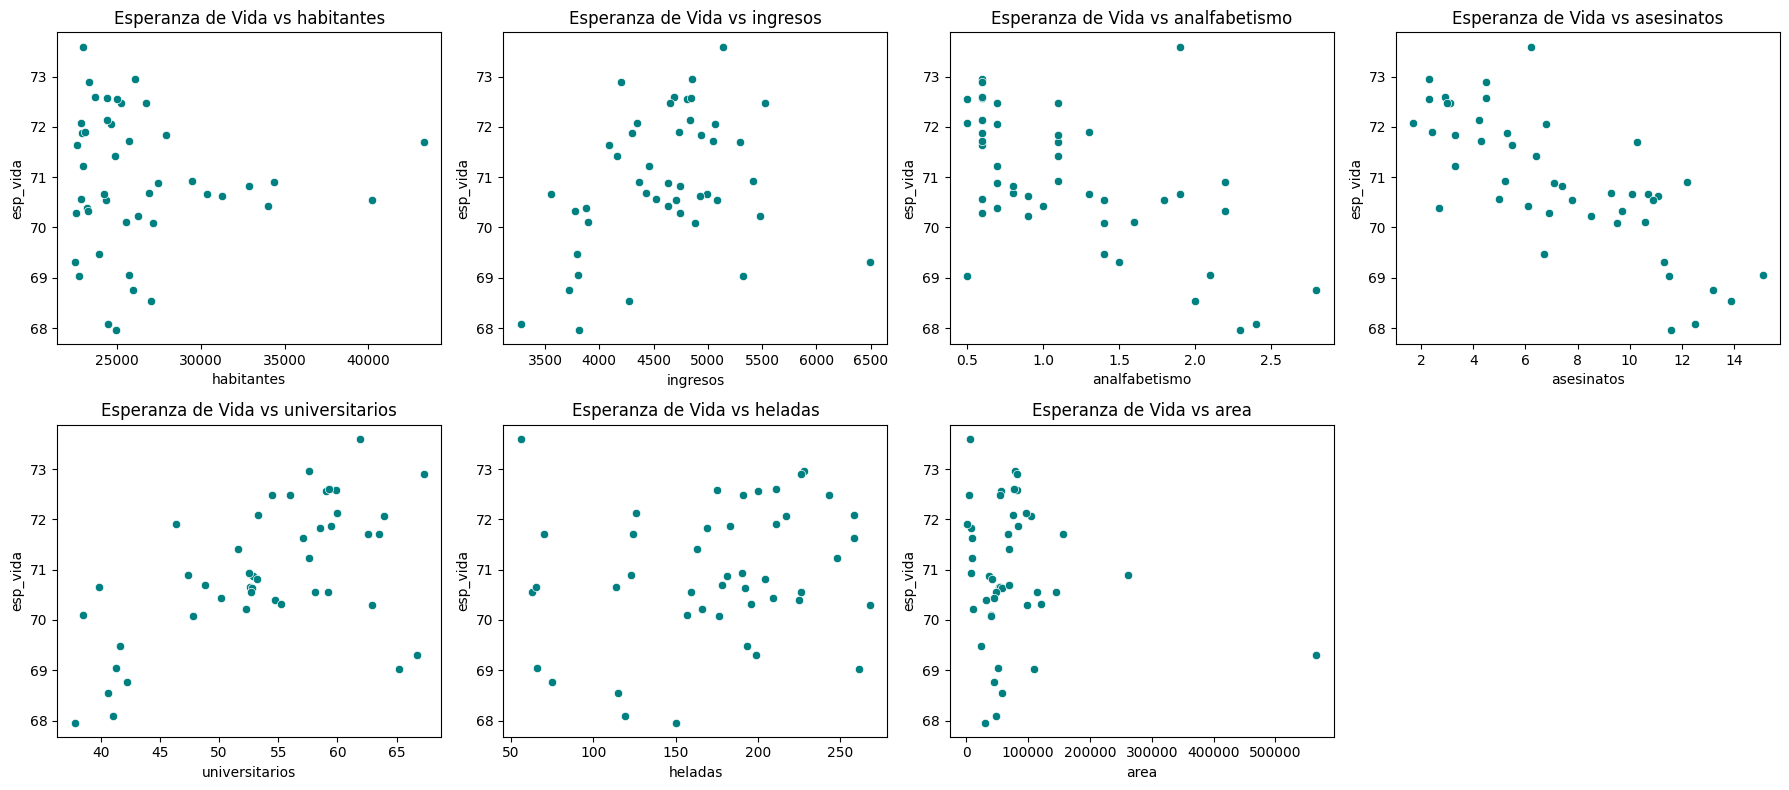

In [ ]:
#gráficos de dispersión entre esperanza de vida y cada predictor
predictores = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten() # Aplana la matriz de ejes para iterar fácilmente

for i, predictor in enumerate(predictores):
    sns.scatterplot(data=df_esp, x=predictor, y='esp_vida', ax=axes[i], color='teal')
    axes[i].set_title(f'Esperanza de Vida vs {predictor}')


fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

Interpretaciones:
Al analizar la relación con la esperanza de vida, destacan tres predictores principales. La tasa de asesinatos y el analfabetismo presentan fuertes correlaciones negativas (-0.769 y -0.588, respectivamente), indicando que a mayores tasas de estos indicadores, menor es la longevidad. En contraste, el porcentaje de universitarios muestra una correlación positiva fuerte (0.591), asociándose con una mayor esperanza de vida. Por su parte, variables como el número de habitantes y el área territorial muestran alta dispersión y correlaciones casi nulas, sugiriendo un nulo poder predictivo individual.

En la matriz de correlaciones destaca la alta correlación entre asesinatos y analfabetismo (0.705), así como las fuertes relaciones inversas del analfabetismo con las heladas (-0.661) y los universitarios (-0.651). Este nivel de asociación entre las variables independientes evidencia un riesgo de multicolinealidad. Para solucionarlo, es necesario emplear métodos de selección que descarten la información redundante y construyan un modelo estadístico más limpio y eficiente.

In [ ]:
from scipy import stats

#definir la variable respuesta y los predictores iniciales
y = df_esp['esp_vida']
predictores_disponibles = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']
predictores_seleccionados = []

alpha = 0.01

print("--- INICIO DE SELECCIÓN PROGRESIVA (FORWARD) ---")

while True:
    p_valores = {}

    # 1.ajustar el modelo base (anidado)
    if len(predictores_seleccionados) == 0:
        # Modelo nulo: Solo contiene el intercepto
        X_base = np.ones((len(y), 1))
    else:
        # Modelo con las variables ya seleccionadas
        X_base = sm.add_constant(df_esp[predictores_seleccionados])

    modelo_base = sm.OLS(y, X_base).fit()
    RSS_base = modelo_base.ssr  # Suma de cuadrados residual del modelo base

    # 2.evaluar la incorporación de cada variable disponible
    for predictor in predictores_disponibles:
        # Ajustar modelo nuevo añadiendo el predictor a evaluar
        X_nuevo = sm.add_constant(df_esp[predictores_seleccionados + [predictor]])
        modelo_nuevo = sm.OLS(y, X_nuevo).fit()

        RSS_nuevo = modelo_nuevo.ssr
        df_resid = modelo_nuevo.df_resid # Grados de libertad (n - p - 1)

        # Cálculo del estadístico F parcial para 1 variable añadida
        F_stat = ((RSS_base - RSS_nuevo) / 1) / (RSS_nuevo / df_resid)

        # Calcular el p-valor exacto usando la distribución F
        p_val = stats.f.sf(F_stat, 1, df_resid)
        p_valores[predictor] = p_val

    # 3. Identificar la variable que más mejora el modelo (menor valor-p)
    mejor_predictor = min(p_valores, key=p_valores.get)
    mejor_p_valor = p_valores[mejor_predictor]

    # 4. Verificar si supera el umbral del 1% de significancia
    if mejor_p_valor < alpha:
        predictores_seleccionados.append(mejor_predictor)
        predictores_disponibles.remove(mejor_predictor)
        print(f"Paso {len(predictores_seleccionados)}: Se añade '{mejor_predictor}' (p-valor = {mejor_p_valor:.6e})")
    else:
        print(f"\nFin: Ninguna variable restante cumple el criterio p < {alpha}.")
        print(f"El candidato rechazado más cercano fue '{mejor_predictor}' (p = {mejor_p_valor:.4f})")
        break

print("\n--- ORDEN DE INGRESO ---")
print(predictores_seleccionados)

print("\n--- MODELO FINAL ---")
X_final = sm.add_constant(df_esp[predictores_seleccionados])
modelo_final = sm.OLS(y, X_final).fit()
print(modelo_final.summary())

# Supongamos que tu modelo se llama "modelo", "modelo_simple" o "modelo_final"
# Guardas el resumen estadístico
resumen_modelo = modelo.summary()

# Lo exportas a LaTeX
print(resumen_modelo.as_latex())

--- INICIO DE SELECCIÓN PROGRESIVA (FORWARD) ---
Paso 1: Se añade 'asesinatos' (p-valor = 6.454427e-10)
Paso 2: Se añade 'universitarios' (p-valor = 8.871117e-03)
Paso 3: Se añade 'heladas' (p-valor = 2.073712e-03)

Fin: Ninguna variable restante cumple el criterio p < 0.01.
El candidato rechazado más cercano fue 'habitantes' (p = 0.0650)

--- ORDEN DE INGRESO ---
['asesinatos', 'universitarios', 'heladas']

--- MODELO FINAL ---
                            OLS Regression Results                            
Dep. Variable:               esp_vida   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     36.31
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           1.28e-11
Time:                        03:48:15   Log-Likelihood:                -47.624
No. Observations:                  45   AIC:                             103.2
Df Residuals: 

Interpretaciones:

El modelo incorporó las variables en el siguiente orden: primero 'asesinatos', luego 'universitarios' y finalmente 'heladas'.

Valor-p asociado a cada incorporación:
- asesinatos: ingresó con un valor-p de 6.45e-10.
- universitarios: ingresó con un valor-p de 0.00887.
- heladas: ingresó con un valor-p de 0.00207.
El proceso se detuvo ahí porque la opción más cercana, 'habitantes', obtuvo un p-valor de 0.0650, superando el límite exigido de 0.01.

El modelo definitivo retiene solo tres predictores y se define con la siguiente ecuación:
esp_vida = 71.4714 - 0.2896*(asesinatos) + 0.0532*(universitarios) - 0.0074*(heladas)

Este modelo resulta estadísticamente válido en su conjunto (Estadístico F = 36.31, Prob F = 1.28e-11) y logra explicar un 72.7% de la variabilidad en la esperanza de vida.

In [ ]:
predictores_actuales = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']
alpha = 0.01
eliminadas = []

print("--- INICIO DE SELECCIÓN REGRESIVA (BACKWARD) ---")

while len(predictores_actuales) > 0:
    # 1.ajustar el modelo base (con las variables que van quedando)
    X_base = sm.add_constant(df_esp[predictores_actuales])
    modelo_base = sm.OLS(y, X_base).fit()
    RSS_base = modelo_base.ssr
    df_resid_base = modelo_base.df_resid

    p_valores = {}

    # 2.evaluar qué pasa si sacamos cada variable, una por una
    for predictor in predictores_actuales:
        predictores_reducidos = [p for p in predictores_actuales if p != predictor]

        # Ajustar modelo sin esa variable
        if len(predictores_reducidos) == 0:
            X_reducido = np.ones((len(y), 1))
        else:
            X_reducido = sm.add_constant(df_esp[predictores_reducidos])

        modelo_reducido = sm.OLS(y, X_reducido).fit()
        RSS_reducido = modelo_reducido.ssr

        # Cálculo del test F parcial comparando los dos modelos
        F_stat = ((RSS_reducido - RSS_base) / 1) / (RSS_base / df_resid_base)
        p_val = stats.f.sf(F_stat, 1, df_resid_base)
        p_valores[predictor] = p_val

    # 3.buscar la variable menos significativa (la que tiene el p-valor más ALTO)
    peor_predictor = max(p_valores, key=p_valores.get)
    peor_p_valor = p_valores[peor_predictor]

    # 4.si el p-valor es mayor a 0.01, la sacamos del modelo
    if peor_p_valor > alpha:
        predictores_actuales.remove(peor_predictor)
        eliminadas.append((peor_predictor, peor_p_valor))
        print(f"Se elimina '{peor_predictor}' (p-valor = {peor_p_valor:.4f})")
    else:
        print(f"\nFin: Todas las variables restantes son significativas al {alpha*100}%.")
        break

print("\n--- ORDEN DE ELIMINACIÓN ---")
for var, p in eliminadas:
    print(f"- {var} (p={p:.4f})")

print("\n--- MODELO FINAL ---")
X_final = sm.add_constant(df_esp[predictores_actuales])
modelo_final = sm.OLS(y, X_final).fit()
print(modelo_final.summary())

# Supongamos que tu modelo se llama "modelo", "modelo_simple" o "modelo_final"
# Guardas el resumen estadístico
resumen_modelo = modelo.summary()

# Lo exportas a LaTeX
print(resumen_modelo.as_latex())

--- INICIO DE SELECCIÓN REGRESIVA (BACKWARD) ---
Se elimina 'analfabetismo' (p-valor = 0.8167)
Se elimina 'ingresos' (p-valor = 0.7330)
Se elimina 'area' (p-valor = 0.6296)
Se elimina 'habitantes' (p-valor = 0.0650)

Fin: Todas las variables restantes son significativas al 1.0%.

--- ORDEN DE ELIMINACIÓN ---
- analfabetismo (p=0.8167)
- ingresos (p=0.7330)
- area (p=0.6296)
- habitantes (p=0.0650)

--- MODELO FINAL ---
                            OLS Regression Results                            
Dep. Variable:               esp_vida   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     36.31
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           1.28e-11
Time:                        03:48:39   Log-Likelihood:                -47.624
No. Observations:                  45   AIC:                             103.2
Df Residuals:           

Interpretaciones:

Partiendo con un modelo completo, el algoritmo fue descartando las variables menos útiles en el siguiente orden: primero 'analfabetismo', luego 'ingresos', después 'area' y finalmente 'habitantes'.

Valor-p asociado a cada decisión de eliminación:
- analfabetismo: se eliminó por tener el valor-p más alto de 0.8167.
- ingresos: se eliminó con un valor-p de 0.7330.
- area: se eliminó con un valor-p de 0.6296.
- habitantes: se eliminó con un valor-p de 0.0650.
El proceso se detuvo en este punto porque todas las variables que quedaron dentro del modelo demostraron ser significativas, con valores-p por debajo del límite estricto de 0.01.

El modelo definitivo es matemáticamente idéntico al obtenido en la selección progresiva, reteniendo los mismos tres predictores con la siguiente ecuación:
esp_vida = 71.4714 - 0.2896*(asesinatos) + 0.0532*(universitarios) - 0.0074*(heladas)

Este modelo es globalmente válido (Estadístico F = 36.31, Prob F = 1.28e-11) y logra capturar un 72.7% de la varianza en la esperanza de vida.

In [ ]:
predictores = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']
respuesta = 'esp_vida'
alpha = 0.01

def seleccion_stepwise(df, lista_predictores, var_respuesta, umbral=0.01):
    incluidas = []

    print("--- INICIO DE SELECCIÓN STEPWISE BIDIRECCIONAL ---")

    while True:
        cambio = False

        # 1. PASO FORWARD (Evaluar qué variable agregar)
        excluidas = list(set(lista_predictores) - set(incluidas))
        p_valores_forward = {}

        for nueva_var in excluidas:
            # Ajustar modelo temporal con la variable candidata
            variables_prueba = incluidas + [nueva_var]
            X_prueba = sm.add_constant(df[variables_prueba])
            modelo = sm.OLS(df[var_respuesta], X_prueba).fit()
            # Guardar el p-valor de la candidata
            p_valores_forward[nueva_var] = modelo.pvalues[nueva_var]

        if p_valores_forward:
            # Buscar la candidata con el p-valor más bajo
            mejor_var = min(p_valores_forward, key=p_valores_forward.get)
            mejor_p_valor = p_valores_forward[mejor_var]

            # Si supera el umbral, entra al modelo
            if mejor_p_valor < umbral:
                incluidas.append(mejor_var)
                cambio = True
                print(f"Paso Forward: Ingresa '{mejor_var}' (p-valor = {mejor_p_valor:.2e})")

        # 2. PASO BACKWARD (Revisar las variables que ya están adentro)
        if incluidas:
            X_actual = sm.add_constant(df[incluidas])
            modelo_actual = sm.OLS(df[var_respuesta], X_actual).fit()

            # Sacar los p-valores de las variables incluidas (omitiendo la constante)
            p_valores_backward = modelo_actual.pvalues.drop('const')
            peor_var = p_valores_backward.idxmax()
            peor_p_valor = p_valores_backward.max()

            # Si la peor variable ahora supera el umbral, se elimina
            if peor_p_valor > umbral:
                incluidas.remove(peor_var)
                cambio = True
                print(f"Paso Backward: Se elimina '{peor_var}' (p-valor = {peor_p_valor:.4f})")

        # Si el algoritmo dio una vuelta completa sin agregar ni quitar nada, termina.
        if not cambio:
            print(f"\nFin: El modelo se ha estabilizado bajo el criterio del {umbral*100}%.")
            break

    return incluidas

# Ejecutar la función
variables_finales = seleccion_stepwise(df_esp, predictores, respuesta, umbral=alpha)

# Mostrar el modelo final
print("\n--- MODELO FINAL ---")
X_final = sm.add_constant(df_esp[variables_finales])
modelo_final = sm.OLS(df_esp[respuesta], X_final).fit()
print(modelo_final.summary())

# Supongamos que tu modelo se llama "modelo", "modelo_simple" o "modelo_final"
# Guardas el resumen estadístico
resumen_modelo = modelo.summary()

# Lo exportas a LaTeX
print(resumen_modelo.as_latex())

--- INICIO DE SELECCIÓN STEPWISE BIDIRECCIONAL ---
Paso Forward: Ingresa 'asesinatos' (p-valor = 6.45e-10)
Paso Forward: Ingresa 'universitarios' (p-valor = 8.87e-03)
Paso Forward: Ingresa 'heladas' (p-valor = 2.07e-03)

Fin: El modelo se ha estabilizado bajo el criterio del 1.0%.

--- MODELO FINAL ---
                            OLS Regression Results                            
Dep. Variable:               esp_vida   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     36.31
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           1.28e-11
Time:                        03:48:50   Log-Likelihood:                -47.624
No. Observations:                  45   AIC:                             103.2
Df Residuals:                      41   BIC:                             110.5
Df Model:                           3                           

Interpretaciones:

Trayectoria del algoritmo:
El método comenzó desde un modelo nulo y evaluó las variables en ambas direcciones. En los pasos hacia adelante (forward), el algoritmo incorporó 'asesinatos' (valor-p = 6.45e-10), luego 'universitarios' (valor-p = 8.87e-03) y finalmente 'heladas' (valor-p = 2.07e-03). En las revisiones hacia atrás (backward), no fue necesario eliminar ninguna variable, ya que todas mantuvieron valores-p inferiores al umbral estricto de 0.01 al ajustarse junto a los nuevos predictores. El modelo se estabilizó al no haber más variables que cumplieran el criterio de entrada ni de salida.

El resultado converge exactamente al mismo modelo de las selecciones anteriores, reteniendo las mismas tres variables explicativas con la siguiente ecuación:
esp_vida = 71.4714 - 0.2896*(asesinatos) + 0.0532*(universitarios) - 0.0074*(heladas)

Este ajuste presenta una significancia global contundente (Estadístico F = 36.31, Prob F = 1.28e-11) y explica el 72.7% de la varianza en la respuesta.

In [ ]:
#ajustar el modelo COMPLETO (para obtener la varianza residual estimada, sigma^2)
predictores_todos = ['habitantes', 'ingresos', 'analfabetismo', 'asesinatos', 'universitarios', 'heladas', 'area']
X_completo = sm.add_constant(df_esp[predictores_todos])
modelo_completo = sm.OLS(y, X_completo).fit()
sigma2_estimado = modelo_completo.mse_resid  # Varianza del error del modelo completo

#ajustar el modelo FINAL (el de las 3 variables que ganaron)
predictores_final = ['asesinatos', 'universitarios', 'heladas']
X_final = sm.add_constant(df_esp[predictores_final])
modelo_final = sm.OLS(y, X_final).fit()

#extraer métricas directas del modelo final
r2_ajustado = modelo_final.rsquared_adj
aic = modelo_final.aic
bic = modelo_final.bic

#calcular el Cp de Mallows manualmente
rss_p = modelo_final.ssr  # Suma de cuadrados residuales del modelo final
n = modelo_final.nobs     # Número total de observaciones (45)
p = modelo_final.df_model + 1  # Cantidad de parámetros (3 variables + 1 constante = 4)

cp_mallows = (rss_p / sigma2_estimado) - n + 2 * p

#crear la tabla con un diccionario y pasarla a DataFrame
datos_tabla = {
    'Modelo': ['Forward', 'Backward', 'Stepwise'],
    'R2_aj': [r2_ajustado, r2_ajustado, r2_ajustado],
    'Cp': [cp_mallows, cp_mallows, cp_mallows],
    'AIC': [aic, aic, aic],
    'BIC': [bic, bic, bic]
}

tabla_comparativa = pd.DataFrame(datos_tabla)

#imprimir la tabla redondeando a 3 decimales para que se vea ordenada
print("--- TABLA DE COMPARACIÓN DE MODELOS ---")
print(tabla_comparativa.round(3).to_string(index=False))

# Exportar la tabla comparativa de modelos
print(tabla_comparativa.to_latex(index=False, float_format="%.3f"))

--- TABLA DE COMPARACIÓN DE MODELOS ---
  Modelo  R2_aj   Cp     AIC     BIC
 Forward  0.707 3.76 103.249 110.475
Backward  0.707 3.76 103.249 110.475
Stepwise  0.707 3.76 103.249 110.475
\begin{tabular}{lrrrr}
\toprule
Modelo & R2_aj & Cp & AIC & BIC \\
\midrule
Forward & 0.707 & 3.760 & 103.249 & 110.475 \\
Backward & 0.707 & 3.760 & 103.249 & 110.475 \\
Stepwise & 0.707 & 3.760 & 103.249 & 110.475 \\
\bottomrule
\end{tabular}



Se elige el modelo con los predictores 'asesinatos', 'universitarios' y 'heladas' porque los tres métodos de búsqueda (forward, backward y stepwise) llegaron exactamente a este mismo resultado.

Evaluando los indicadores:

- R2 ajustado: Se busca que sea lo más grande posible, ya que indica cuánta variabilidad de la esperanza de vida logra explicar el modelo penalizando el exceso de variables. El valor de 0.707 es bastante alto y nos asegura que la información explicada es real y no está inflada.

- Cp de Mallows, AIC y BIC: Estos tres indicadores se prefieren lo más pequeños posible. Sirven para evaluar el equilibrio entre un buen ajuste a los datos y la simplicidad matemática. Que tengan valores bajos (AIC = 103.2, BIC = 110.5) nos confirma que el error está controlado y que el modelo no tiene predictores de sobra.

- Parsimonia e interpretación: El principio de parsimonia indica que siempre es mejor quedarse con el modelo más simple. Al bajar de 7 variables a solo 3, el modelo queda súper limpio y evitamos problemas matemáticos como la colinealidad. Esto facilita enormemente la interpretación estadística, ya que podemos explicar de forma directa y clara cómo influyen los homicidios, la educación y el clima en la esperanza de vida, sin que el resto de las variables metan ruido innecesario.